# Icy Dicey Propagation

**Group assignment 1.6 — computer-based preparation**

Work through the notebook together. At 11:30, laptops close and the group receives a separate one-hour written assignment. Keep your derivations and numerical results in **handwritten notes**; these are the only reference material you may use during the written hour.

We compare Taylor propagation and Monte Carlo simulation, then investigate their limitations.

## Ice growth during a cold spell

In a simplified Stefan model, the thickness after a period of freezing is

$$
H_{ice}=q(H_{ice,0},\Delta T)
=\sqrt{\frac{2 k_{ice}}{\rho_{ice}l}\,\Delta T\,\Delta t+H_{ice,0}^{2}}.
$$

The thermal parameters are $k_{ice}=2.2\ \mathrm{W/(m\,K)}$, $\rho_{ice}=917\ \mathrm{kg/m^3}$ and $l=333.4\ \mathrm{kJ/kg}$. For numerical calculations, use the rounded coefficient:

$$\frac{2 k_{ice}}{\rho_{ice}l}=1.44\times10^{-8}\ \mathrm{m^2/(K\,s)}.$$

$H_{ice,0}$ is the initial ice thickness, $\Delta t$ is the duration in seconds, and $\Delta T$ is the temperature deficit relative to the freezing point, in Kelvin. The model assumes that temperatures remain constant during each simulated cold spell, ice properties are constant, and heat transfer is dominated by conduction.

**Input model:** $H_{ice,0}\sim\mathcal{N}(0.20\ \mathrm{m},(0.03\ \mathrm{m})^2)$ and $\Delta T\sim\mathcal{N}(10\ \mathrm{K},(4\ \mathrm{K})^2)$, initially assumed independent. They represent uncertain estimates of the initial thickness and temperature deficit; all other quantities are deterministic. The principal prediction time is $\Delta t=5$ days.

The Gaussian assumption assigns a small probability to $\Delta T<0$ (above-freezing conditions). **For the simulation only**, negative temperature deficits are set to zero: $\Delta T_{growth}=\max(\Delta T,0)$. This simplified model assumes no additional ice growth when the air is above freezing; it **does not simulate melting**. Consequently, the simulated input is no longer exactly Gaussian. For the Taylor approximation, we expand at the positive mean $\mu_{\Delta T}=10\ \mathrm{K}$, where the square-root model is smooth. This difference in treatment is part of the model assessment.

The symbols $\mu_{H_0}=E(H_{ice,0})$ and $\sigma_{H_0}$ denote the initial-thickness mean and standard deviation, while $\mu_{\Delta T}$ and $\sigma_{\Delta T}$ refer to the temperature deficit. $\mathrm{Cov}(H_{ice,0},\Delta T)$ denotes their covariance.

## Part 1 — Understanding the physical model

> **Task 1.1:** Run the check below, verify the units of the expression inside the square root, and discuss what happens if $\Delta T=0$. In your notes, record the formula and the two physical modelling assumptions that matter most for interpreting the results.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Use the rounded coefficient specified in the assignment.
constant = 1.44e-8             # m^2 / (K s)
time = 5 * 24 * 3600          # s
mu_H0, sigma_H0 = 0.20, 0.03 # m
mu_iT, sigma_iT = 10.0, 4.0 # K

def stefan(constant, H0, iT, time):
    """Ice thickness (m) with a temperature deficit (K) and no melting."""
    return np.sqrt(constant * time * np.maximum(iT, 0) + H0**2)

print('Deterministic test (H0=0.15 m, iT=12 K, 5 days):',
      f'{stefan(constant, mu_H0, mu_iT, time):.3f} m')
print('No-growth test:', f'{stefan(constant, 0.20, 0.0, time):.3f} m')

Deterministic test (H0=0.15 m, iT=12 K, 5 days): 0.320 m
No-growth test: 0.200 m


## Part 2 — Propagating the mean and variance

At $\mu_{H_0}=0.20$ m and $\mu_{\Delta T}=10$ K, derive the first and second partial derivatives of $q$ and apply the formulas from the lecture:

$$\begin{aligned}
\mu_H&\approx q(\mu_{H_0},\mu_{\Delta T})
+\frac12\left(\frac{\partial^2q}{\partial H_{ice,0}^2}\right)_0\sigma_{H_0}^2
+\frac12\left(\frac{\partial^2q}{\partial (\Delta T)^2}\right)_0\sigma_{\Delta T}^2
+\left(\frac{\partial^2q}{\partial H_{ice,0}\partial(\Delta T)}\right)_0\mathrm{Cov}(H_{ice,0},\Delta T),\\
\sigma_H^2&\approx \left(\frac{\partial q}{\partial H_{ice,0}}\right)_0^2\sigma_{H_0}^2
+\left(\frac{\partial q}{\partial(\Delta T)}\right)_0^2\sigma_{\Delta T}^2
+2\left(\frac{\partial q}{\partial H_{ice,0}}\right)_0
\left(\frac{\partial q}{\partial(\Delta T)}\right)_0\mathrm{Cov}(H_{ice,0},\Delta T).
\end{aligned}$$

As in the lecture, the subscript $0$ indicates evaluation at the mean of the input variables. The first line is a **second-order approximation to the mean** and the second line a **first-order approximation to the variance**; neither is generally exact for this non-linear model.

> **Task 2.1:** Complete `H_taylor`. Include the covariance terms so that the function also works when the correlation coefficient $\rho$ is not zero. Do not use symbolic libraries. Write your derivatives on paper and keep them for the written assignment.

In [59]:
def H_taylor(mu_H0, mu_iT, sigma_H0, sigma_iT, time, rho=0.0):
    """Second-order mean and first-order standard deviation; units: m."""
    constant = 1.44e-8
    # Evaluate derivatives at (mu_H0, mu_iT).
    # rho is the Pearson correlation of the two input variables.
    # Replace each ... with a Python expression.
    H_at_mean = stefan(constant, mu_H0, mu_iT, time)  
    dH_dH0 = mu_H0/((H_at_mean))
    dH_diT = constant * time / (2 * H_at_mean)
    d2H_dH02 = (constant * time * mu_iT)/ (H_at_mean**(3))
    d2H_diT2 = -((constant * time)**2)/(4*(H_at_mean**(3)))
    d2H_dH0diT = (-1/2)*(constant * time * mu_H0)/ (H_at_mean**(3))
    cov_H0_iT = rho * sigma_H0 * sigma_iT

    mu_H = H_at_mean + 0.5 * (d2H_dH02 * sigma_H0**2 + d2H_diT2 * sigma_iT**2 + 2 * d2H_dH0diT * cov_H0_iT)
    var_H = (dH_dH0 * sigma_H0)**2 + (dH_diT * sigma_iT)**2 + 2 * dH_dH0 * dH_diT * cov_H0_iT
    sigma_H = np.sqrt(var_H)
    return mu_H, sigma_H


> **Task 2.2:** Calculate the predicted mean and standard deviation for five days. Check that both have units of metres. Compare the second-order mean with the value of $q$ at the mean inputs. Record the numerical results.

In [60]:
mu_H, sigma_H = H_taylor(mu_H0, mu_iT, sigma_H0, sigma_iT, time)
H_at_mean = stefan(constant, mu_H0, mu_iT, time)
print(f'q(mean inputs)       = {H_at_mean:.6f} m')
print(f'Taylor mean          = {mu_H:.6f} m')
print(f'Taylor standard dev. = {sigma_H:.6f} m')

q(mean inputs)       = 0.319700 m
Taylor mean          = 0.318188 m
Taylor standard dev. = 0.043206 m


## Part 3 — Monte Carlo uncertainty propagation

Generate realizations of $H_{ice,0}$ and $\Delta T$ from their assumed Gaussian distributions. Evaluate the non-linear Stefan model for each pair and estimate the output mean and sample standard deviation. Use `np.mean` and `np.std(..., ddof=1)`, consistent with the $N-1$ denominator in the sample-variance expression from the textbook.

> **Task 3.1:** Complete `H_monte_carlo`. Use `np.random.default_rng(seed)` for reproducible results. For $\rho=0$ generate two independent Gaussian samples. For nonzero $\rho$, use `rng.multivariate_normal`, which was introduced for joint Gaussian sampling. The clipping of negative deficits must happen **after** drawing the samples. Return the fraction of clipped deficits to help assess this modelling choice.

In [57]:
def H_monte_carlo(N, mu_H0, mu_iT, sigma_H0, sigma_iT,
                  time, rho=0.0, seed=1606):
    """Return MC mean, sample standard deviation, output and clipped fraction."""
    rng = np.random.default_rng(seed)
    if rho == 0.0:
        H0_samples = norm.rvs(mu_H0, sigma_H0, size=N, random_state=rng)
        iT_samples = norm.rvs(mu_iT, sigma_iT, size=N, random_state=rng)
    else:
        cov_H0_iT = rho * sigma_H0 * sigma_iT
        cov = np.array([[sigma_H0**2, cov_H0_iT],
                        [cov_H0_iT, sigma_iT**2]])
        pairs = rng.multivariate_normal([mu_H0, mu_iT], cov, size=N)
        H0_samples, iT_samples = pairs[:, 0], pairs[:, 1]

    clipped_fraction = len(iT_samples[iT_samples < 0]) / len(iT_samples)  # proportion of iT_samples that are negative
    H_samples = stefan(constant, H0_samples, iT_samples, time)
    mu_H_simulated = np.mean(H_samples)
    sigma_H_simulated = np.std(H_samples, ddof=1)
    return mu_H_simulated, sigma_H_simulated, H_samples, clipped_fraction


> **Task 3.2:** Run $N=100000$ simulations. Compare the simulated moments with the Taylor approximations. The discrepancy consists of Taylor approximation error, Monte Carlo sampling variability and, in this exercise, the effect of clipping negative temperature deficits. Avoid interpreting a finite simulation as the exact physical distribution.

In [58]:
N = 100_000
mu_H_sim, sigma_H_sim, H_samples, clipped_fraction = H_monte_carlo(
    N, mu_H0, mu_iT, sigma_H0, sigma_iT, time, seed=1606)
print(f'MC mean             = {mu_H_sim:.6f} m')
print(f'MC standard dev.    = {sigma_H_sim:.6f} m')
print(f'Clipped deficits    = {100*clipped_fraction:.3f}%')
print(f'MC - Taylor mean    = {mu_H_sim-mu_H:+.6f} m')
print(f'MC - Taylor std     = {sigma_H_sim-sigma_H:+.6f} m')

MC mean             = 0.318273 m
MC standard dev.    = 0.044155 m
Clipped deficits    = 0.615%
MC - Taylor mean    = +0.000085 m
MC - Taylor std     = +0.000949 m


## Part 4 — Shape of the output distribution and lower-tail risk

A Gaussian approximation with moments $(\mu_H,\sigma_H)$ can be useful even when the transformed output is not exactly Gaussian. For rare events, inspect the lower tail rather than relying on the agreement between mean and standard deviation.

> **Task 4.1:** Use the plots below to compare the Monte Carlo distribution with the Gaussian approximation based on the Taylor moments. Which distribution would you use if unusually thin ice matters? Note what the histogram can and cannot establish.

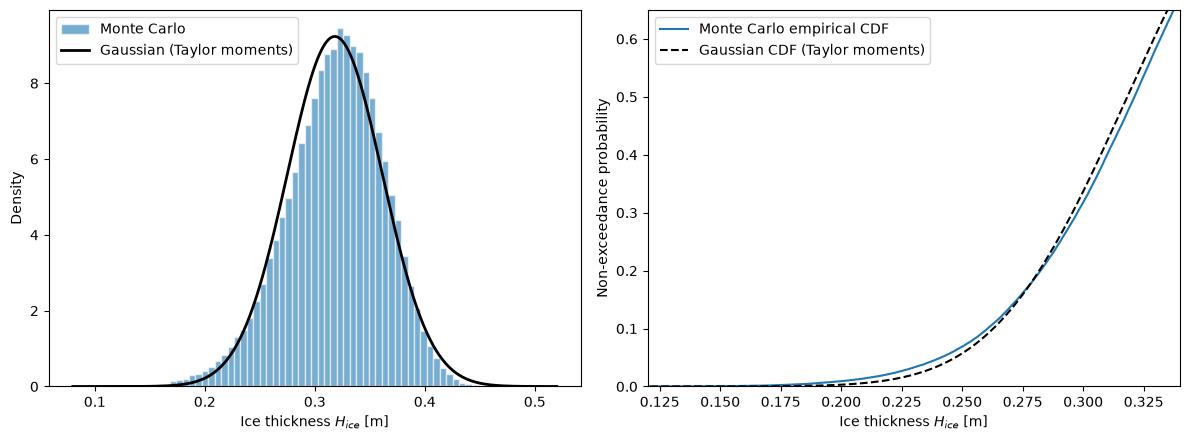

In [69]:
x = np.linspace(0.08, 0.52, 450)
sorted_H = np.sort(H_samples)
p_emp = (np.arange(1, N+1) / N)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].hist(H_samples, bins=65, density=True, alpha=0.6,
           label='Monte Carlo', edgecolor='white')
ax[0].plot(x, norm.pdf(x, loc=mu_H, scale=sigma_H), 'k-',
           label='Gaussian (Taylor moments)', lw=2)
ax[0].set(xlabel='Ice thickness $H_{ice}$ [m]', ylabel='Density')
ax[0].legend()
ax[1].plot(sorted_H, p_emp, label='Monte Carlo empirical CDF')
ax[1].plot(x, norm.cdf(x, loc=mu_H, scale=sigma_H), 'k--',
           label='Gaussian CDF (Taylor moments)')
ax[1].set(xlabel='Ice thickness $H_{ice}$ [m]', ylabel='Non-exceedance probability',
          xlim=(0.12, 0.34), ylim=(0, 0.65))
ax[1].legend()
fig.tight_layout()
plt.show()

> **Task 4.2:** Quantify the chance that the ice is thinner than $0.24\ \mathrm{m}$ after five days: (i) use the empirical CDF from the Monte Carlo samples, and (ii) use the Gaussian CDF based on the Taylor moments. Interpret the difference for a hypothetical safety decision. Record both probabilities in your notes.

In [52]:
H_limit = 0.24  # m
p_empirical = np.mean(H_samples < H_limit)
p_gaussian = norm.cdf(H_limit, loc=mu_H, scale=sigma_H)
print(f'P(H_ice < {H_limit:.2f} m), Monte Carlo  = {p_empirical:.5f}')
print(f'P(H_ice < {H_limit:.2f} m), Gaussian    = {p_gaussian:.5f}')
print(f'Absolute difference                 = {abs(p_empirical-p_gaussian):.5f}')

P(H_ice < 0.24 m), Monte Carlo  = 0.04783
P(H_ice < 0.24 m), Gaussian    = 0.03517
Absolute difference                 = 0.01266


## Part 5 — Sample size and input dependence

> **Task 5.1:** Repeat the independent-input simulation for $N=100$, $1000$, $10000$ and $100000$, using the same seed. What becomes more stable as $N$ grows? Note that a larger $N$ reduces sampling error; it does **not** correct errors in the physical model or in its input distributions.

In [53]:
print('N       MC mean [m]   MC std [m]   P(H<0.24 m)')
for n in [100, 1000, 10000, 100000]:
    mean_n, std_n, h_n, _ = H_monte_carlo(
        n, mu_H0, mu_iT, sigma_H0, sigma_iT, time, seed=1606)
    print(f'{n:6d}  {mean_n:11.6f}  {std_n:11.6f}  {np.mean(h_n<H_limit):12.5f}')

N       MC mean [m]   MC std [m]   P(H<0.24 m)
   100     0.313031     0.046730       0.06000
  1000     0.316415     0.045331       0.05800
 10000     0.317523     0.044552       0.05260
100000     0.318273     0.044155       0.04783


Now suppose initial thickness and the forecast temperature deficit have a **positive Pearson correlation** of $\rho=0.5$. This is a hypothetical change in the joint input model, not a measured property of the ice.

> **Task 5.2:** Use the Taylor formula with $\mathrm{Cov}(H_{ice,0},\Delta T)=\rho\sigma_{H_0}\sigma_{\Delta T}$ and the joint-Gaussian sampler above to investigate the difference. Write down the sign of the covariance contribution to the output variance and the results for $\rho=0$ and $\rho=0.5$. Why does the output uncertainty change?

In [66]:
rho = 0.5
mu_H_corr, sigma_H_corr = H_taylor(mu_H0, mu_iT, sigma_H0, sigma_iT,
                                   time, rho=rho)
mu_MC_corr, sigma_MC_corr, H_corr, frac_corr = H_monte_carlo(
    N, mu_H0, mu_iT, sigma_H0, sigma_iT, time, rho=rho, seed=1606)
print('                           rho=0        rho=0.5')
print(f'Taylor mean [m]       {mu_H:12.6f} {mu_H_corr:12.6f}')
print(f'Taylor std [m]        {sigma_H:12.6f} {sigma_H_corr:12.6f}')
print(f'Monte Carlo mean [m]  {mu_H_sim:12.6f} {mu_MC_corr:12.6f}')
print(f'Monte Carlo std [m]   {sigma_H_sim:12.6f} {sigma_MC_corr:12.6f}')
print(len(H_corr), frac_corr)

                           rho=0        rho=0.5
Taylor mean [m]           0.318188     0.317046
Taylor std [m]            0.043206     0.050962
Monte Carlo mean [m]      0.318273     0.316976
Monte Carlo std [m]       0.044155     0.052515
100000 0.00583


## Before laptops close: your handwritten notes

Check that everyone in your group can explain your calculations. Your notes should contain:

1. The Stefan growth equation, assumptions, given input moments and units.
2. The first and second partial derivatives of $q$ and the Taylor propagation formulas, including the covariance terms.
3. Numerical results for $q$ at the mean inputs, the Taylor and Monte Carlo mean and standard deviation, and the fraction of simulated deficits clipped to zero.
4. The empirical and Gaussian probabilities for $H_{ice}<0.24$ m, with your interpretation of the lower tail.
5. The influence of sample size and the effect of setting $\rho=0.5$, including the sign of the covariance contribution.

**At 11:30:** stop using computers, we will distribute the separate written assignment and you have to submit one set of handwritten answers (per each group) at 12:30.

> By Lotfi Massarweh and Sandra Verhagen, Delft University of Technology. CC BY 4.0, more info [on the Credits page of Workbook](https://mude.citg.tudelft.nl/workbook-2026/credits.html).